# 感知机
## 感知机
给定输入 $x$，权重 $w$ 和偏移量 $b$，感知机的输出为
$$o = \sigma(w \cdot x + b),\space \sigma(x) = \begin{cases} 1, & x > 0 \\ 0, & x \leq 0 \end{cases}$$

## 多层感知机
- 输入 $x \in \mathbb{R}^{n}$
- 隐藏层 $W_1 \in \mathbb{R}^{m \times n}, b_1 \in \mathbb{R}^{m}$
- 输出层 $W_2 \in \mathbb{R}^{k \times m}, b_2 \in \mathbb{R}^{k}$
- 输出 $o = \sigma(W_2 \cdot \sigma(W_1 \cdot x + b_1) + b_2)$


# MLP 从零实现


In [1]:
import torch
from torch import nn


单隐藏层，256 个隐藏单元，10 个输出单元

In [2]:
class MLP:
    def __init__(self, num_inputs, num_hiddens, num_outputs):
        self.num_inputs = num_inputs
        self.num_hiddens = num_hiddens
        self.num_outputs = num_outputs
        self.loss = nn.CrossEntropyLoss() # 损失函数
        self.w1 = nn.Parameter(torch.randn(self.num_inputs, self.num_hiddens, requires_grad=True))
        self.b1 = nn.Parameter(torch.zeros(self.num_hiddens, requires_grad=True))
        self.w2 = nn.Parameter(torch.randn(self.num_hiddens, self.num_outputs, requires_grad=True))
        self.b2 = nn.Parameter(torch.zeros(self.num_outputs, requires_grad=True))
        self.params = [self.w1, self.b1, self.w2, self.b2]
        self.updater = torch.optim.SGD(self.params, lr=0.1) # 优化器

    @staticmethod
    def relu(x):
        """ReLU 激活函数"""
        # zeros_like 返回一个与 x 形状和类型相同的全零张量
        return torch.max(x, torch.zeros_like(x))

    def forward(self, x):
        """前向传播"""
        x = x.reshape((-1, self.num_inputs)) # 展平
        h = self.relu(x @ self.w1 + self.b1) # 隐藏层
        return h @ self.w2 + self.b2 # 输出层

    def train_ch3(self, train_iter, test_iter, num_epochs):
        """训练模型"""
        from util import train_ch3
        train_ch3(self, train_iter, test_iter, self.loss, num_epochs, self.updater)


加载数据


In [3]:
from util import load_data_fashion_mnist
batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size)

训练 10 个 epoch

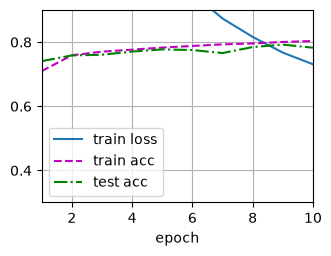

In [16]:
num_epochs = 10
model = MLP(num_inputs=784, num_hiddens=256, num_outputs=10)
model.train_ch3(train_iter, test_iter, num_epochs)

# MLP 简洁实现


In [17]:
mlp = nn.Sequential(
    nn.Flatten(), # 展平
    nn.Linear(784, 256), # 全连接层
    nn.ReLU(), # ReLU 激活函数
    nn.Linear(256, 10) # 全连接层
)
loss = nn.CrossEntropyLoss() # 损失函数
trainer = torch.optim.SGD(mlp.parameters(), lr=0.1) # 优化器

# 初始化
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)
mlp.apply(init_weights)   

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=10, bias=True)
)

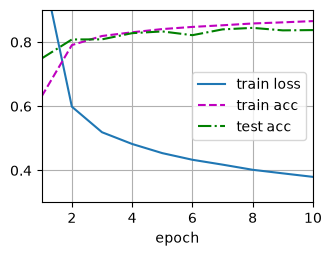

In [18]:
from util import train_ch3
train_iter, test_iter = load_data_fashion_mnist(batch_size)
train_ch3(mlp, train_iter, test_iter, loss, num_epochs, trainer)